In [42]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import os 
import sys

In [43]:

# Charger le fichier EEG 
raw = mne.io.read_raw_edf("../data/raw/AE129/AE129_231121C-A.edf", preload=True) 

# Afficher les infos
raw.info


Extracting EDF parameters from c:\Users\Dessalines\Desktop\Cerco_studies\data\raw\AE129\AE129_231121C-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9428991  =      0.000 ... 36831.996 secs...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_17316\1366059515.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("../data/raw/AE129/AE129_231121C-A.edf", preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG C3, EEG C4, EEG T3, EEG T4, EEG O1, EEG ...
 chs: 33 EEG
 custom_ref_applied: False
 highpass: 10.0 Hz
 lowpass: 100.0 Hz
 meas_date: 2023-11-21 21:54:59 UTC
 nchan: 33
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: 051211AE, sex: 2, first_name: ABRAMYAN, last_name: EDITH, birthday: 2011-12-05>
>

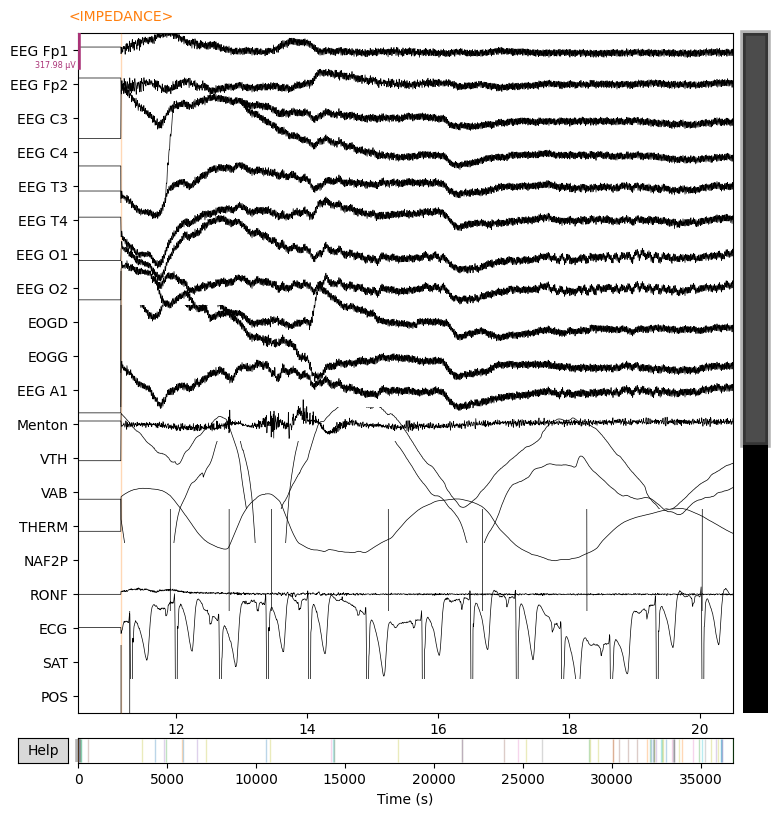

In [44]:
# Afficher le plot
raw.plot(n_channels=20, start=10.5 , duration=10, scalings='auto', show=False)


In [45]:
print(raw.ch_names)


['EEG Fp1', 'EEG Fp2', 'EEG C3', 'EEG C4', 'EEG T3', 'EEG T4', 'EEG O1', 'EEG O2', 'EOGD', 'EOGG', 'EEG A1', 'Menton', 'VTH', 'VAB', 'THERM', 'NAF2P', 'RONF', 'ECG', 'SAT', 'POS', 'PTT', 'PCO2', 'FC', 'Pouls', 'JAMBG', 'JAMBD', 'EMG2', 'EMG1', 'EEG Cz', 'EEG Pz', 'SPo2_Cap', 'SLI', 'CPAP']


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


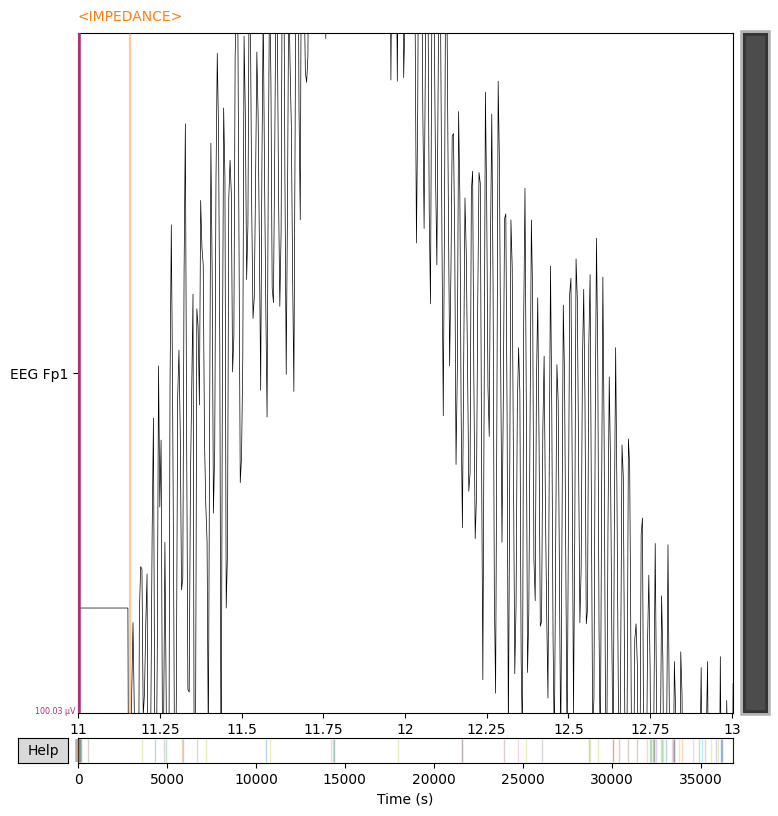

In [47]:
# Si on affiche un seul canal...
channel_name = 'EEG Fp1'

# Extraire uniquement ce canal
raw_single_channel = raw.copy().pick_channels([channel_name])

# Plot
raw_single_channel.plot(start=11, duration=2, scalings='auto', show=False)


Extracting EDF parameters from c:\Users\Dessalines\Desktop\Cerco_studies\data\raw\GX111\200924e-aex_0001.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 14591  =      0.000 ...    56.996 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_17316\268966589.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("../data/raw/GX111/200924e-aex_0001.edf", preload=True)


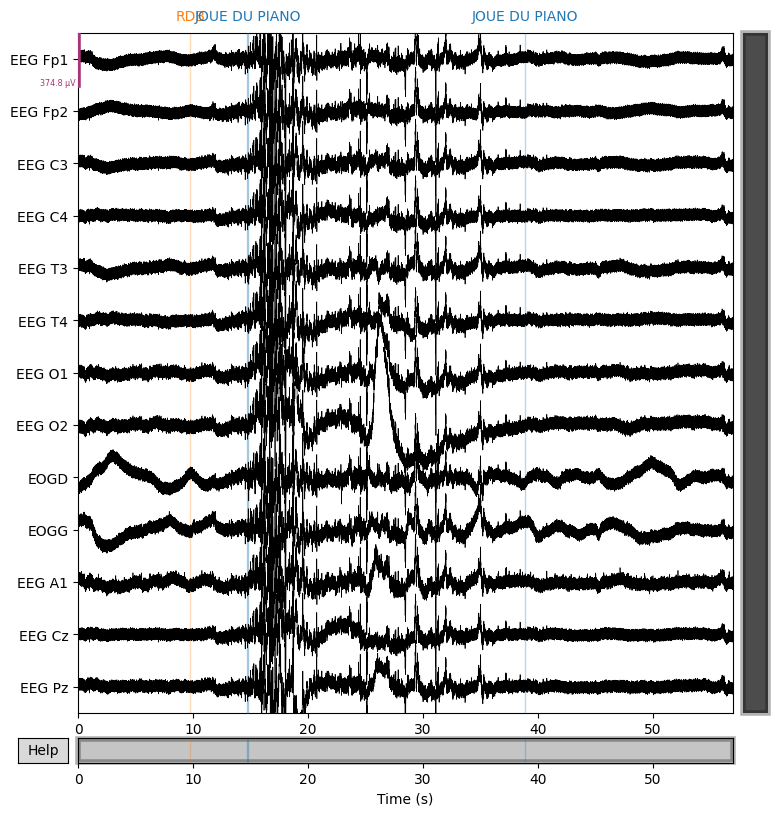

In [53]:
# Ne garder que les canaux eegs

raw = mne.io.read_raw_edf("../data/raw/GX111/200924e-aex_0001.edf", preload=True) 
eeg_channels = [ch for ch in raw.ch_names if ch.startswith('EEG ') or ch.startswith('EOG')]
raw_eeg = raw.copy().pick_channels(eeg_channels)

# Plot
raw_eeg.plot(n_channels=len(raw_eeg.ch_names),start= 0, duration=60, scalings='auto', show=False)



### Prétraitement des artéfacts avec ICA

In [27]:
# Visualiser un segment long (e.g. 2 minutes)
from preprocessing import preprocess_eeg_file
from mne.io import read_raw_fif

edf_path = "../data/raw/AE129/AE129_231121C-A.edf"
preprocess_eeg_file(edf_path)


Extracting EDF parameters from c:\Users\Dessalines\Desktop\Cerco_studies\data\raw\AE129\AE129_231121C-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9428991  =      0.000 ... 36831.996 secs...


c:\Users\Dessalines\Desktop\Cerco_studies\src\preprocessing.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:    2.5s finished


Fitting ICA to data using 13 channels (please be patient, this may take a while)
Selecting by explained variance: 13 components
Fitting ICA took 109.0s.
Using EOG channel: EOGD
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidt

[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


Applying ICA to Raw instance
    Transforming to ICA space (13 components)
    Zeroing out 1 ICA component
    Projecting back using 13 PCA components
Writing c:\Users\Dessalines\Desktop\Cerco_studies\notebooks\data\preprocessed\AE129_231121C-A_eeg_cleaned_raw.fif
Closing c:\Users\Dessalines\Desktop\Cerco_studies\notebooks\data\preprocessed\AE129_231121C-A_eeg_cleaned_raw.fif
[done]
 AE129_231121C-A prétraité et sauvegardé dans data/preprocessed\AE129_231121C-A_eeg_cleaned_raw.fif


Opening raw data file ../data/preprocessed/200924e-aex_0001_eeg_cleaned_raw.fif...
Isotrak not found
    Range : 0 ... 14591 =      0.000 ...    56.996 secs
Ready.
Reading 0 ... 14591  =      0.000 ...    56.996 secs...


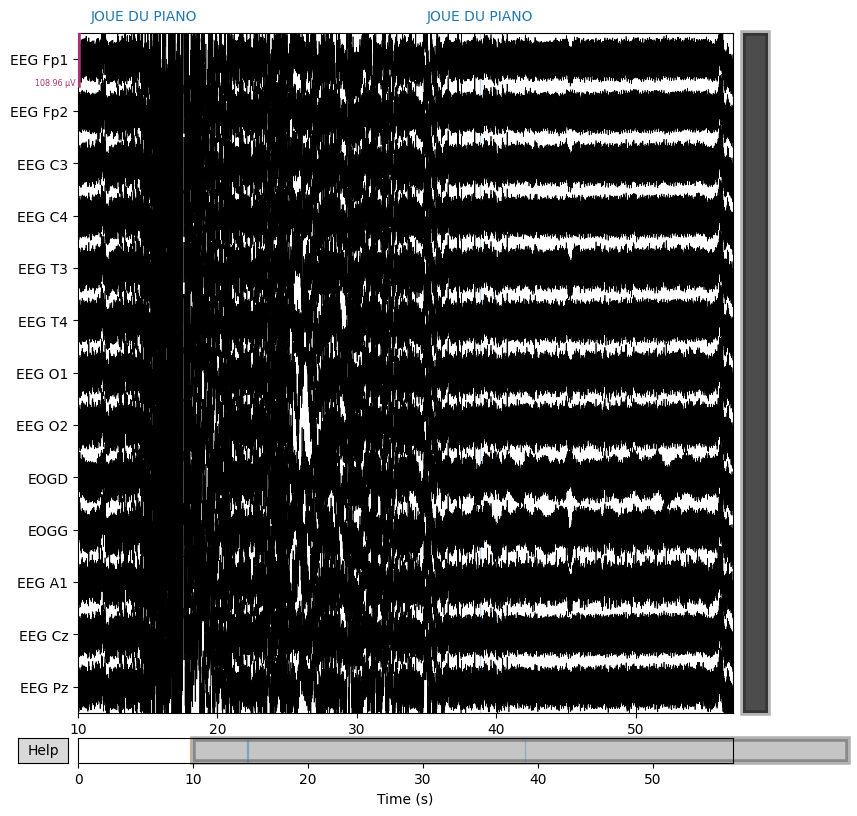

In [55]:
cleaned_path = "../data/preprocessed/200924e-aex_0001_eeg_cleaned_raw.fif"
raw_clean = read_raw_fif(cleaned_path, preload=True)

raw_clean.plot(duration=60, start=10, n_channels=20, scalings='auto', show=False)


In [36]:
raw_clean.ch_names

['EEG Fp1',
 'EEG Fp2',
 'EEG C3',
 'EEG C4',
 'EEG T3',
 'EEG T4',
 'EEG O1',
 'EEG O2',
 'EOGD',
 'EOGG',
 'EEG A1',
 'EEG Cz',
 'EEG Pz']

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


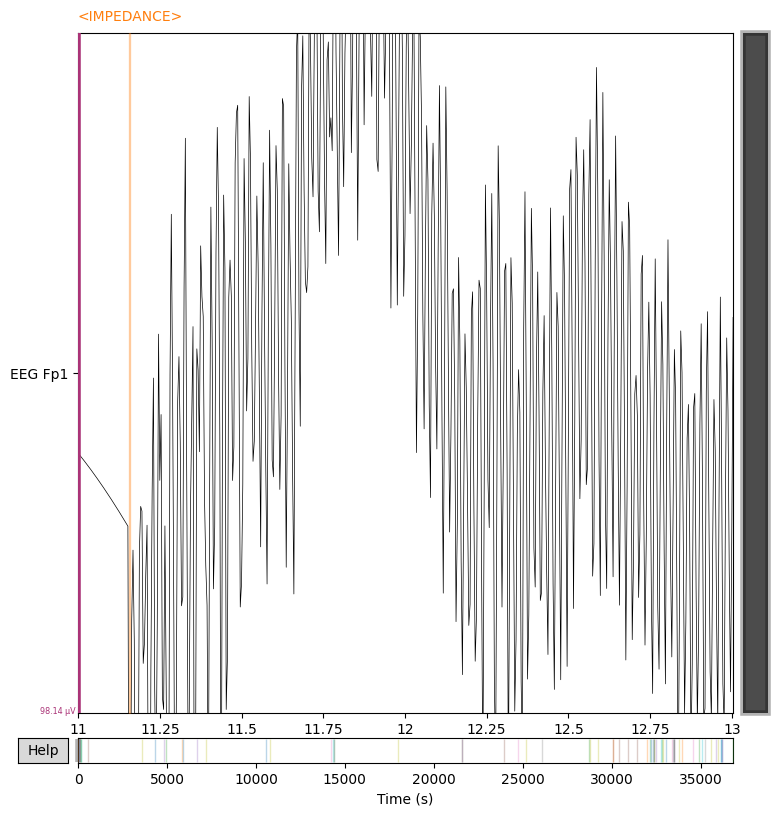

In [48]:
channel_name = 'EEG Fp1' 

# Extraire le canal
raw_single_channel = raw_clean.copy().pick_channels([channel_name])

# Visualisation
raw_single_channel.plot(start=11, duration=2, scalings='auto', show=False)


In [ ]:
# On fais le preprocessing de tous les fichiers : 
import os
import glob
from preprocessing import preprocess_eeg_file

# Recherche récursive dans tous les sous-dossiers de data/raw/
edf_files = glob.glob("../data/raw/**/*.edf", recursive=True)

print(f" {len(edf_files)} fichiers EDF trouvés dans les sous-dossiers.")

# Boucle de prétraitement
for i, edf_file in enumerate(edf_files, 1):
    try:
        print(f"\n {i}/{len(edf_files)} - Prétraitement de {os.path.basename(edf_file)}")
        preprocess_eeg_file(edf_file, save_dir="../data/preprocessed")
    except Exception as e:
        print(f" Erreur sur {edf_file} : {e}")


In [33]:
import sys
import os

# Ajoute le dossier src/ au path si besoin
sys.path.append(os.path.abspath("../src"))

from cohort import load_patient_groups, group_edf_files_by_pathology

# Chargement de la feuille 3 du fichier Excel
excel_path = "../data/nv_patientsRBD_identifiants.xlsx"
df, group_map = load_patient_groups(excel_path, sheet_index=2)

# Aperçu des premières lignes
df.head()


TypeError: load_patient_groups() got an unexpected keyword argument 'sheet_index'